<ipython-input-3-d5873055dd2c>:15: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000**(-t)
<ipython-input-3-d5873055dd2c>:28: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


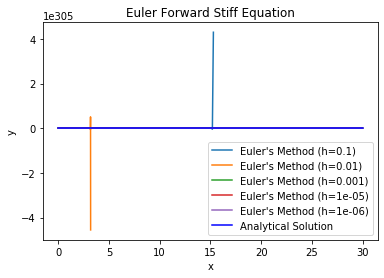

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 30

def Parameters(h):
    
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1  # y(0) = 1
    return num_steps, x_values, y_values

def f(t, y):
    return -1000*y + 3000 - 2000**(-t)

def analytical_solution(t):
    return 3 - 0.998**(-1000*t) - 2.002**(-t)
    
h_values = np.array([.1, .01, .001, .00001, .000001])

for h in h_values:
    
    num_steps, x_values, y_values = Parameters(h)
    
    for i in range(num_steps):

        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    plt.plot(x_values, y_values, label=f'Euler\'s Method (h={h})')
    
x_analytical = np.linspace(x_start, x_end, 1000)
y_analytical = analytical_solution(x_analytical)
plt.plot(x_analytical, y_analytical, 'b-', label='Analytical Solution')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Euler Forward Stiff Equation')
plt.legend()
plt.show()